In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# from avaframe.in3Utils import generateTopo as gT
# from avaframe.in3Utils import cfgUtils

In [ ]:
def getParabolaParams(cfg):
    """Compute parameters for parabola"""

    # input parameters
    C = float(cfg["TOPO"]["C"])
    fLens = float(cfg["TOPO"]["fLens"])
    meanAlpha = float(cfg["TOPO"]["meanAlpha"])

    # If mean slope is given or distance to the start of the flat plane
    if meanAlpha != 0:
        fLen = C / np.tan(np.radians(meanAlpha))
        # log.info("fLen computed from mean alpha: %.2f meters" % fLen)
    else:
        fLen = fLens
        # log.info("flen directly set to: %.2f meters" % fLen)
    A = C / (fLen**2)
    B = (-C * 2.0) / fLen

    return A, B, fLen

def getGridDefs(cfg):
    # determine number of rows and columns to define domain
    dx = float(cfg["TOPO"]["dx"])
    xEnd = float(cfg["TOPO"]["xEnd"])
    yEnd = float(cfg["TOPO"]["yEnd"])

    return dx, xEnd, yEnd

def computeCoordGrid(dx, xEnd, yEnd):

    # Compute coordinate grid
    xv = np.arange(0, xEnd + dx, dx)
    yv = np.arange(-0.5 * yEnd, 0.5 * (yEnd + dx), dx)
    nRows = len(yv)
    nCols = len(xv)
    x, y = np.meshgrid(xv, yv)
    zv = np.zeros((nRows, nCols))

    return xv, yv, zv, x, y, nRows, nCols

def genericTopo():
    """
    Compute coordinates of an S-shaped slope as a generic topography for debris-flow simulations
    defined by a 4th-degree polynomial: ax**4 + bx**3 + cx**2 + dx + e
    The parameters of the polynomial function are derived from real watershed profiles (Kessler 2019)
    """
    # input parameters
    # cff = float(cfg["CHANNELS"]["cff"])
    # cRadius = float(cfg["CHANNELS"]["cRadius"])
    # cInit = float(cfg["CHANNELS"]["cInit"])
    # cMustart = float(cfg["CHANNELS"]["cMustart"])
    # cMuend = float(cfg["CHANNELS"]["cMuend"])

    cff = 60
    cRadius = 100
    cInit = 250
    cMustart = 0.5
    cMuend = 0.5

    # Get grid definitons
    # dx, xEnd, yEnd = getGridDefs(cfg)

    xEnd = 1380
    yEnd = 1500
    dx = 5

    # Compute coordinate grid
    # xv, yv, zv, x, y, nRows, nCols = computeCoordGrid(dx, xEnd, yEnd)

    xv = np.arange(0, xEnd + dx, dx)
    yv = np.arange(-0.5 * yEnd, 0.5 * (yEnd + dx), dx)
    x, y = np.meshgrid(xv, yv)
    nRows = len(yv)
    nCols = len(xv)

    # Set surface elevation
    zv = np.ones((nRows, nCols))
    zv = zv * (-2.949E-10 * xv ** 4 + 1.21E-06 * xv ** 3 - 0.001462 * xv ** 2 + 0.007059 * xv + 1219)

    # If a channel shall be introduced
    # Get parabola Parameters
    # [A, B, fLen] = getParabolaParams(cfg)
    fLen = 703

    # initialize superimposed channel
    superChannel = np.zeros(np.shape(xv))

    # if cfg["TOPO"].getboolean("channel"):
    c1 = norm.cdf(xv, 0.5 * cMustart * fLen, cff)
    c2 = 1.0 - norm.cdf(xv, 1.5 * cMuend * fLen, cff)

    # combine both into one function separated at the the middle of
    #  the channel longprofile location
    mask = np.zeros(np.shape(xv))
    mask[np.where(xv < (fLen * (0.5 * (cMustart + cMuend))))] = 1
    c0 = c1 * mask

    mask = np.zeros(np.shape(xv))
    mask[np.where(xv >= (fLen * (0.5 * (cMustart + cMuend))))] = 1
    c0 = c0 + c2 * mask


    # Is the channel of constant width or narrowing
    cExtent = cInit * (1 - c0[:]) + (c0[:] * cRadius)
    # else:
    # cExtent = np.zeros(nCols) + cRadius

    # Add surface elevation modification introduced by channel
    mask = np.zeros(np.shape(y))
    mask[np.where(abs(y) < cExtent)] = 1
    mask[:,len(xv):] = 0
    superChannel = (
            superChannel
            + cExtent * c0 * (1.0 - np.sqrt(np.abs(1.0 - (np.square(y) / (cExtent ** 2))))) * mask
    )
    # outside of the channel, add layer of channel thickness
    mask = np.zeros(np.shape(y))
    mask[np.where(abs(y) >= cExtent)] = 1
    superChannel = superChannel + cExtent * c0 * mask
    # else:
    #     superChannel = (
    #             superChannel - cExtent * c0 * np.sqrt(np.abs(1.0 - (np.square(y) / (cExtent ** 2)))) * mask
    #     )

    # add channel and dam
    zv = zv + superChannel

    # # Log info here
    # log.info("Generic topography with s-shaped slope coordinates computed")

    return x, y, zv

In [ ]:
# cfg = cfgUtils.getModuleConfig(gT)
x, y, zv = genericTopo()

In [286]:
# input parameters
cff = 60
cRadius = 100
cInit = 250
cMustart = 0.25
cMuend = 1.15
xEnd = 1380
yEnd = 1500
dx = 5
fLen = 703

xv = np.arange(0, xEnd + dx, dx)
yv = np.arange(-0.5 * yEnd, 0.5 * (yEnd + dx), dx)

# Topographie
x, y = np.meshgrid(xv, yv)

In [307]:
# Set surface elevation
nRows = len(yv)
nCols = len(xv)
zv = np.ones((nRows, nCols))
zv = zv * (-2.949E-10 * xv ** 4 + 1.21E-06 * xv ** 3 - 0.001462 * xv ** 2 + 0.007059 * xv + 1219)

# channel
c1 = norm.cdf(xv, cMustart * fLen, cff) 
c2 = 1.0 - norm.cdf(xv, cMuend * fLen, cff) 

superChannel = np.zeros(np.shape(xv))

# combine both into one function separated at the the middle of
#  the channel longprofile location
mask = np.zeros(np.shape(xv)) 
mask[np.where(xv < (fLen * (0.5 * (cMustart + cMuend))))] = 1 
c0 = c1 * mask

mask = np.zeros(np.shape(xv))
mask[np.where(xv >= (fLen * (0.5 * (cMustart + cMuend))))] = 1
c0 = c0 + c2 * mask

# channel is narrowing
cExtent = cInit * (1 - c0[:]) + (c0[:] * cRadius)
# # channel is of constant width
# nCols = len(xv) 
# cExtent = np.zeros(nCols) + cRadius

# Add surface elevation modification introduced by channel
mask = np.zeros(np.shape(y))
mask[np.where(abs(y) < cExtent)] = 1
# topoAdd = True
superChannel = (
        superChannel
        + cExtent * c0 * (1.0 - np.sqrt(np.abs(1.0 - (np.square(y) / (cExtent ** 2))))) * mask
)
# outside of the channel, add layer of channel thickness
mask = np.zeros(np.shape(y))
mask[np.where(abs(y) >= cExtent)] = 1
cExtent = c2 * cRadius #TODO
superChannel = superChannel + cExtent * mask# * c0 #TODO 
# # topoAdd = False
# superChannel = (
#         superChannel - cExtent * c0 * np.sqrt(np.abs(1.0 - (np.square(y) / (cExtent ** 2)))) * mask
# )

# add channel and dam
zv = zv + superChannel

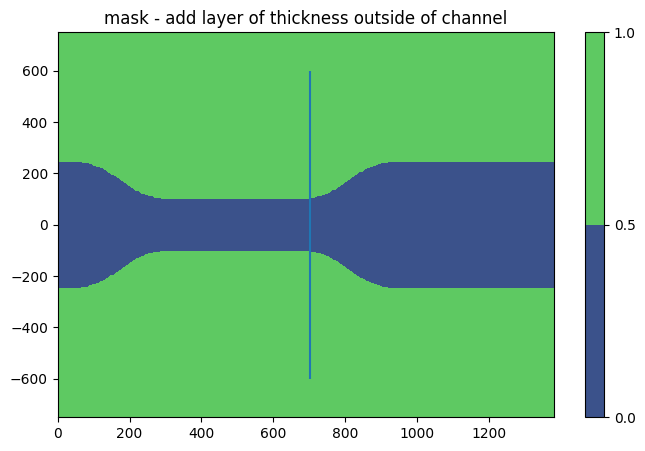

In [308]:
plt.figure(figsize=(8,5))
plt.contourf(x, y, mask, levels=1)
plt.vlines(x = 703, ymax=600, ymin=-600)
plt.title('mask - add layer of thickness outside of channel')
plt.colorbar()
plt.show()

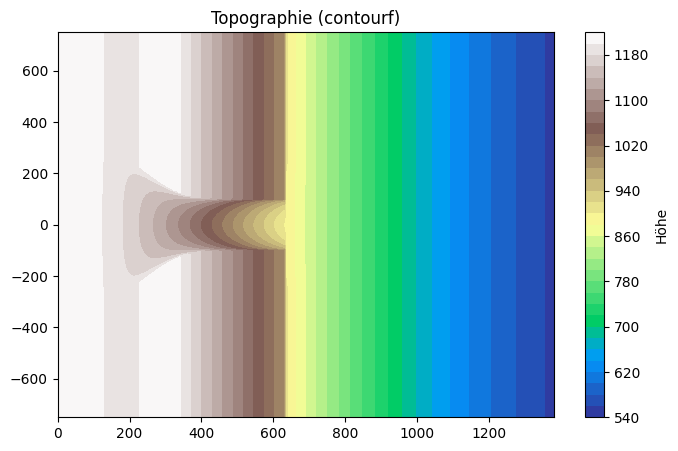

In [212]:
plt.figure(figsize=(8,5))
plt.contourf(x, y, zv, levels=40, cmap='terrain')
plt.colorbar(label='Höhe')
plt.title('Topographie (contourf)')
plt.show()

In [ ]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, zv, cmap='terrain', rstride=1, cstride=1, linewidth=0, antialiased=True)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('Höhe')
plt.title('Topographie (3D)')
plt.show()

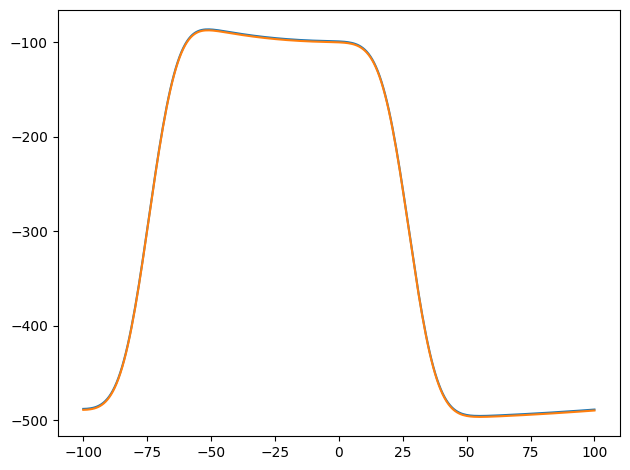

In [114]:
var = np.linspace(-100,100, len(cExtent))
def circle(y, r):
    return - np.sqrt(1 - (np.square(y) / r**2)) * r

plt.plot(var,1- np.sqrt(np.abs(1.0 - (np.square(var) / (cExtent ** 2))))*cExtent)
plt.plot(var, circle(var, cExtent))
# plt.show()
plt.tight_layout()

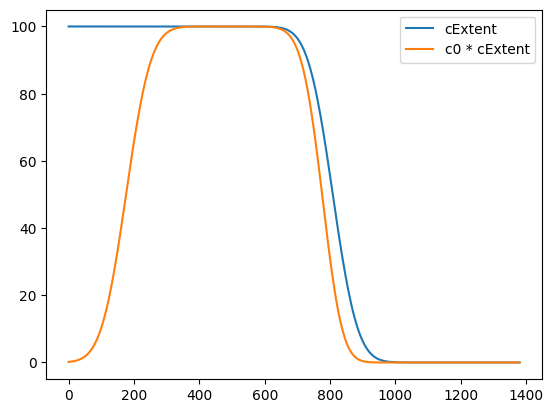

In [306]:
# c0 = 1-norm.cdf(xv, 1.25 * fLen, 60) 
# Plot
# plt.plot(xv, c0*cRadius, label = 'c0 * cRadius')
# plt.plot(xv, c1, label = 'c1')
# plt.plot(xv, c2, label = 'c2')
plt.plot(xv, cExtent, label = 'cExtent')
plt.plot(xv, c0 * cExtent, label = 'c0 * cExtent')
# plt.plot(xv, cRadius, label = 'cExtent')
plt.legend()
plt.show()